In [1]:
import numpy as np
import random

In [2]:
dx = lambda x,y,gamma: -x+x*y-gamma*x**3
dy = lambda x,y,delta,nu: -delta*y+x*y-nu*y**3
ddxx = lambda x,y,gamma: -1+y-3*gamma*x**2
ddxy = lambda x,y: x
ddyx = lambda y,x: y
ddyy = lambda x,y,delta,nu: -delta+x-3*nu*y**2
x0 = 0
x1 = lambda delta,nu,y: delta + nu*y**2
x2 = lambda y: y
y0 = 0
y1 = lambda x: x
y2 = lambda gamma,x: 1 + gamma*x**2
equilibria_x = [x0, x1, x2]  # or keep names clear
equilibria_y = [y0, y1, y2]

In [3]:
x_rand = np.random.uniform(low=1e-4, high=10000, size=100)
y_rand = np.random.uniform(low=1e-4, high=10000, size=100)
gamma = 1
delta = 1
nu = 1

In [4]:
dx_val = dx(x=x_rand, y=y_rand, gamma=gamma)
dy_val = dy(x=x_rand, y=y_rand, delta=delta, nu=nu)

In [5]:
len(dx_val)

100

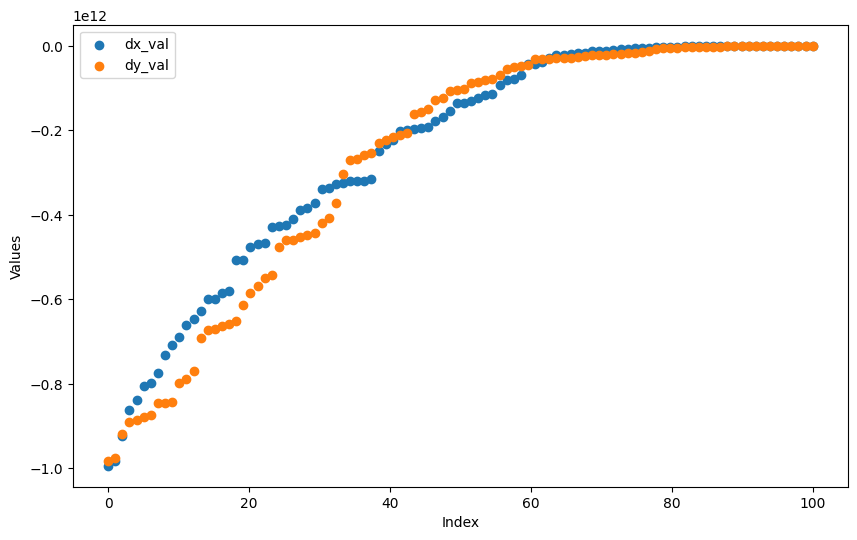

In [6]:
import matplotlib.pyplot as plt
import numpy as np

n = np.linspace(0, len(dy_val), len(dy_val))

plt.figure(figsize=(10, 6))
plt.scatter(n, np.sort(dx_val), label='dx_val')
plt.scatter(n, np.sort(dy_val), label='dy_val')
plt.xlabel('Index')
plt.ylabel('Values')
plt.legend()
plt.show()

In [7]:
# Jacobian matrix
def jacobian(x, y, gamma, delta, nu):
    J = np.array([
        [-1 + y - 3*gamma*x**2, x],
        [y, -delta + x - 3*nu*y**2]
    ])
    return J

In [8]:
# Fixed points (equilibria)
def fixed_points(gamma, delta, nu):
    # (0, 0) is always a fixed point
    fp = [(0, 0)]
    
    # Other fixed points: x = delta + nu*y^2, y = 1/(1 + gamma*x^2)
    # Solve numerically or analytically depending on parameters
    # For now, return the origin
    return fp

In [9]:
# Stability analysis
def stability(x, y, gamma, delta, nu):
    J = jacobian(x, y, gamma, delta, nu)
    eigenvalues = np.linalg.eigvals(J)
    trace = np.trace(J)
    det = np.linalg.det(J)
    
    # Classify fixed point
    if np.all(np.real(eigenvalues) < 0):
        classification = "Stable (node/focus)"
    elif np.all(np.real(eigenvalues) > 0):
        classification = "Unstable (node/focus)"
    else:
        classification = "Saddle"
    
    return eigenvalues, trace, det, classification

In [10]:
# Analyze fixed point (0, 0)
eigs, tr, d, clas = stability(0, 0, gamma, delta, nu)
print(f"Fixed point (0, 0):")
print(f"  Eigenvalues: {eigs}")
print(f"  Trace: {tr}, Det: {d}")
print(f"  Classification: {clas}\n")


Fixed point (0, 0):
  Eigenvalues: [-1. -1.]
  Trace: -2, Det: 1.0
  Classification: Stable (node/focus)



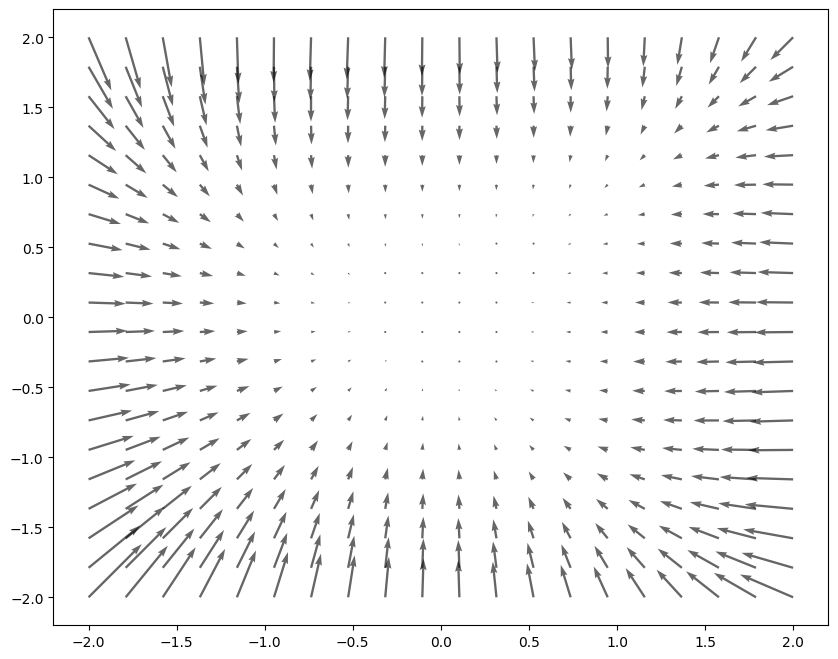

In [11]:

# Phase portrait
fig, ax = plt.subplots(figsize=(10, 8))

# Create grid
X = np.linspace(-2, 2, 20)
Y = np.linspace(-2, 2, 20)
XX, YY = np.meshgrid(X, Y)

# Compute derivatives
U = dx(XX, YY, gamma)
V = dy(XX, YY, delta, nu)

# Quiver plot
ax.quiver(XX, YY, U, V, alpha=0.6)


In [12]:

# Random trajectories
x_rand = np.random.uniform(0.1, 2, 10)
y_rand = np.random.uniform(0.1, 2, 10)

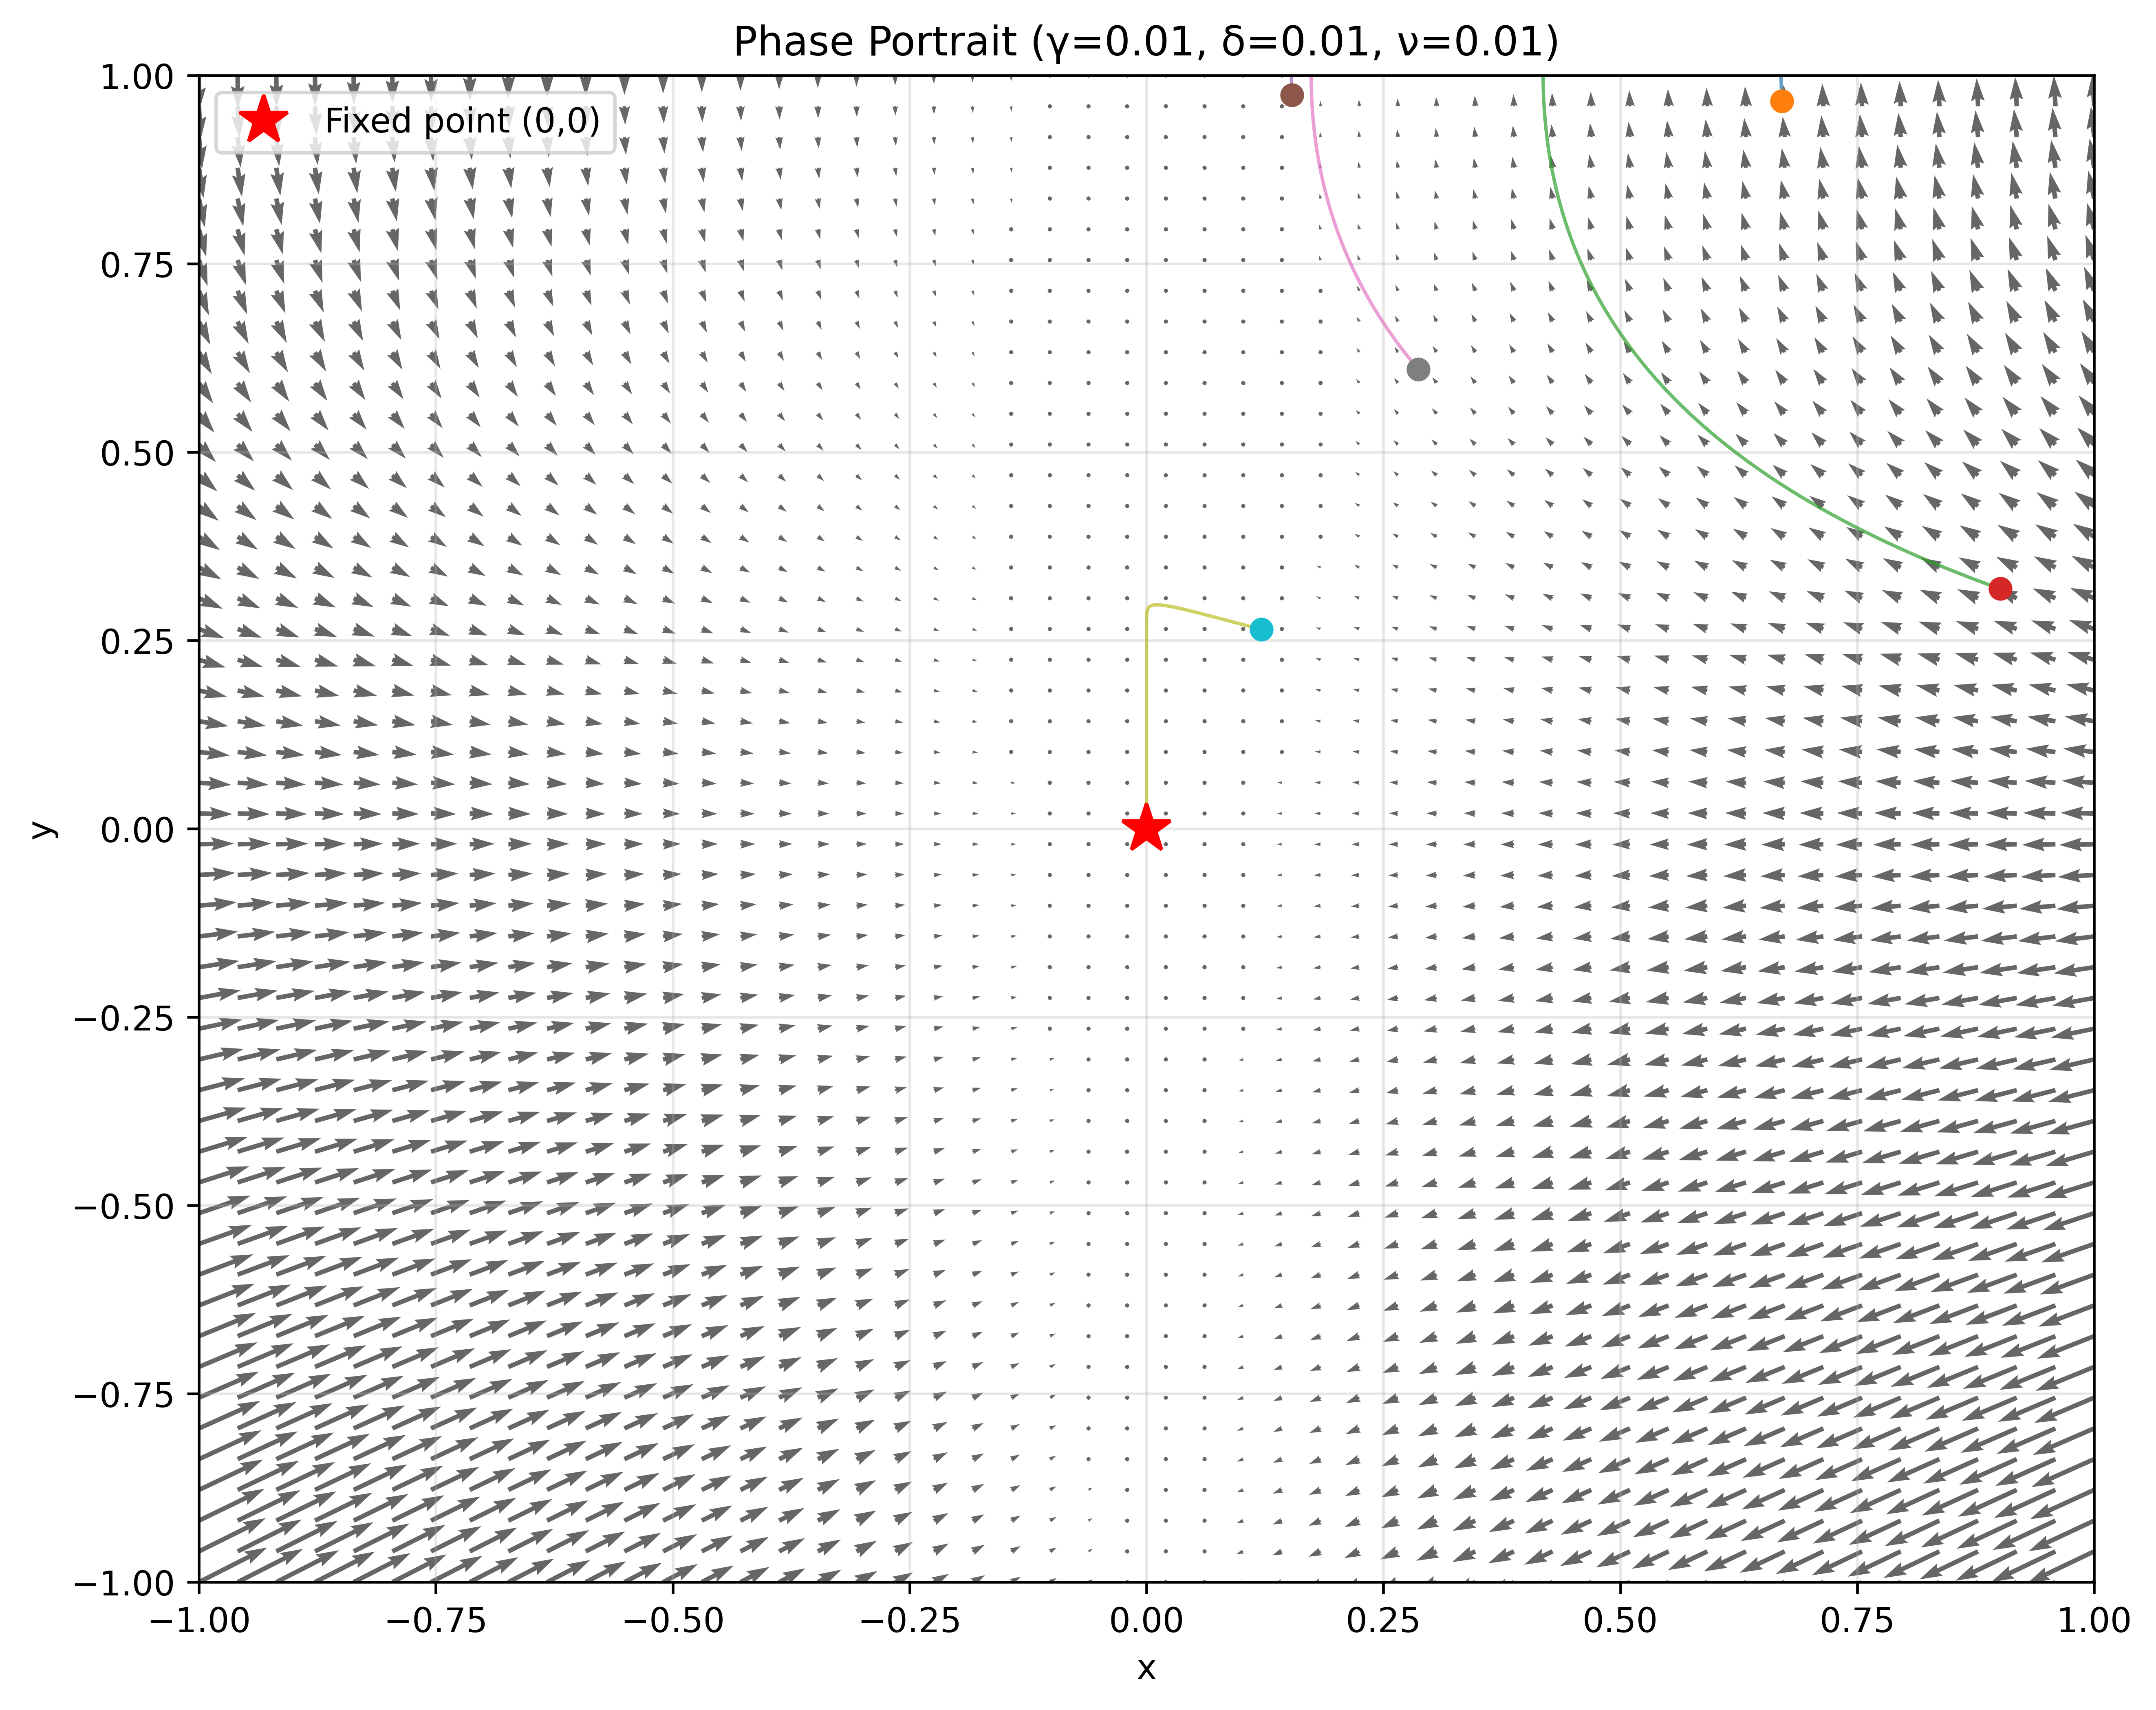

In [33]:
# Simple Euler integration for trajectories
import numpy as np
import matplotlib.pyplot as plt

# System dynamics
dx = lambda x, y, gamma: -x + x*y - gamma*x**3
dy = lambda x, y, delta, nu: -delta*y + x*y - nu*y**3

# Integration function
def integrate_trajectory(x0, y0, gamma, delta, nu, t_max=1000, dt=0.01):
    x, y = x0, y0
    xs, ys = [x], [y]
    for _ in np.arange(0, t_max, dt):
        x += dx(x, y, gamma) * dt
        y += dy(x, y, delta, nu) * dt
        xs.append(x)
        ys.append(y)
    return xs, ys

# Parameters
gamma, delta, nu = 1e-2, 1e-2, 1e-2

# Create figure
fig, ax = plt.subplots(figsize=(10, 8), dpi=600)

# Vector field
X = np.linspace(-1, 1, 50)
Y = np.linspace(-1, 1, 50)
XX, YY = np.meshgrid(X, Y)
U = dx(XX, YY, gamma)
V = dy(XX, YY, delta, nu)
ax.quiver(XX, YY, U, V, alpha=0.6)

# Random initial conditions
x_rand = np.random.uniform(0.001, 1, 100)
y_rand = np.random.uniform(0.001, 1, 100)

# Plot trajectories
for x0, y0 in zip(x_rand[:5], y_rand[:5]):
    xs, ys = integrate_trajectory(x0, y0, gamma, delta, nu)
    ax.plot(xs, ys, alpha=0.7, linewidth=1)
    ax.plot(x0, y0, 'o', markersize=6)

# Fixed point
ax.plot(0, 0, 'r*', markersize=15, label='Fixed point (0,0)')

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title(f'Phase Portrait (γ={gamma}, δ={delta}, ν={nu})')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xlim(-1, 1)
ax.set_ylim(-1, 1)
plt.show()

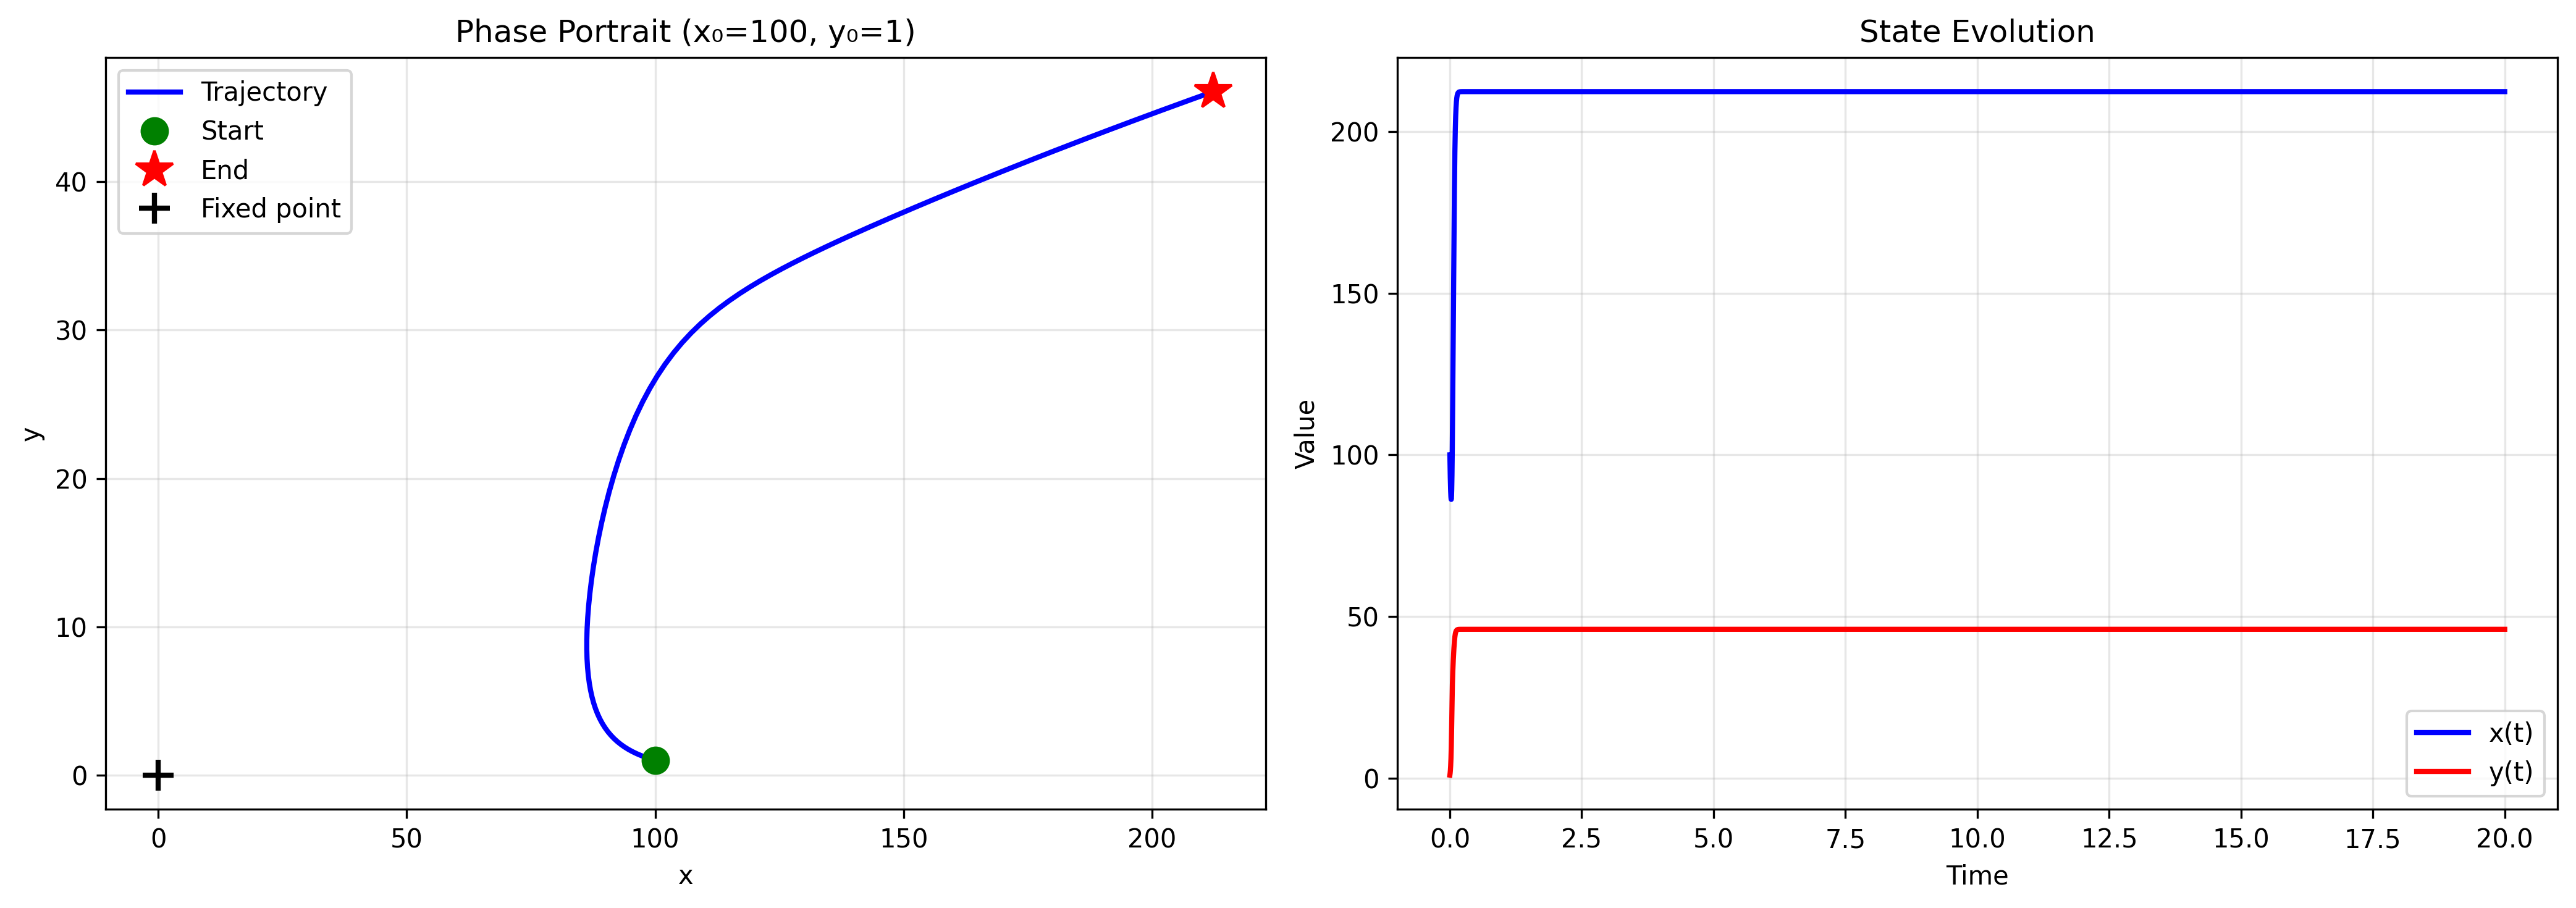

Initial: x=100.0000, y=1.0000
Final:   x=212.3115, y=46.0762
Horizon: 20


In [47]:
def plot_trajectory(x0, y0, gamma, delta, nu, t_max=50, dt=0.001, dpi=300):
    """Plot a single trajectory from initial conditions over time horizon"""
    
    # Integrate
    x, y = x0, y0
    xs, ys = [x], [y]
    ts = [0]
    
    for t in np.arange(0, t_max, dt):
        x += dx(x, y, gamma) * dt
        y += dy(x, y, delta, nu) * dt
        xs.append(x)
        ys.append(y)
        ts.append(t + dt)
    
    # Plot
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), dpi=dpi)
    
    # Phase portrait
    ax1.plot(xs, ys, 'b-', linewidth=2, label='Trajectory')
    ax1.plot(x0, y0, 'go', markersize=10, label='Start')
    ax1.plot(xs[-1], ys[-1], 'r*', markersize=15, label='End')
    ax1.plot(0, 0, 'k+', markersize=12, markeredgewidth=2, label='Fixed point')
    ax1.set_xlabel('x')
    ax1.set_ylabel('y')
    ax1.set_title(f'Phase Portrait (x₀={x0}, y₀={y0})')
    ax1.grid(True, alpha=0.3)
    ax1.legend()
    
    # Time series
    ax2.plot(ts, xs, 'b-', linewidth=2, label='x(t)')
    ax2.plot(ts, ys, 'r-', linewidth=2, label='y(t)')
    ax2.set_xlabel('Time')
    ax2.set_ylabel('Value')
    ax2.set_title('State Evolution')
    ax2.grid(True, alpha=0.3)
    ax2.legend()
    
    plt.tight_layout()
    plt.show()
    
    print(f"Initial: x={x0:.4f}, y={y0:.4f}")
    print(f"Final:   x={xs[-1]:.4f}, y={ys[-1]:.4f}")
    print(f"Horizon: {t_max}")

# Use it
gamma, delta, nu = 0.001, 0.01, 0.1
plot_trajectory(x0=100, y0=1, gamma=gamma, delta=delta, nu=nu, t_max=20, dpi=300)